In [1]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

c:\Users\dharm\anaconda3\envs\fyp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("all_kindle_review .csv")

print(df.shape)
df.head()

(12000, 11)


,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [3]:
def map_rating(rating):
    if rating <= 2:
        return 0      # Negative
    elif rating == 3:
        return 1      # Neutral
    else:
        return 2      # Positive

df["label"] = df["rating"].apply(map_rating)

df["label"].value_counts()

label
2    6000
0    4000
1    2000
Name: count, dtype: int64

In [4]:
df["processed_text"] = df["reviewText"].astype(str)

df[["processed_text","label"]].head()

,processed_text,label
0,"Jace Rankin may be short, but he's nothing to ...",1
1,Great short read. I didn't want to put it dow...,2
2,I'll start by saying this is the first of four...,1
3,Aggie is Angela Lansbury who carries pocketboo...,1
4,I did not expect this type of book to be in li...,2


In [5]:
train_df, test_df = train_test_split(
    df[["processed_text","label"]],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training Samples:", len(train_df))
print("Testing Samples :", len(test_df))

Training Samples: 9600
Testing Samples : 2400


In [6]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['processed_text', 'label', '__index_level_0__'],
    num_rows: 9600
})
Dataset({
    features: ['processed_text', 'label', '__index_level_0__'],
    num_rows: 2400
})


In [7]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

In [8]:
def tokenize_function(examples):
    return tokenizer(
        examples["processed_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [9]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map: 100%|██████████| 2400/2400 [00:00<00:00, 7896.32 examples/s]


In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

print("BERT Loaded")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 426.08it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa

BERT Loaded


In [11]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [12]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./bert_logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Trainer Ready")

Trainer Ready


In [14]:
trainer.train()

c:\Users\dharm\anaconda3\envs\fyp_env\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.575907,0.554920,0.789583,0.767181,0.789583,0.770674
2,0.416505,0.596618,0.791667,0.779357,0.791667,0.784405


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.66it/s]
c:\Users\dharm\anaconda3\envs\fyp_env\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\dharm\anaconda3\envs\fyp_env\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.39it/s]
c:\Users\dharm\anaconda3\envs\fyp_env\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=2400, training_loss=0.5109039306640625, metrics={'train_runtime': 7578.423, 'train_samples_per_second': 2.534, 'train_steps_per_second': 0.317, 'total_flos': 1262944405094400.0, 'train_loss': 0.5109039306640625, 'epoch': 2.0})

In [15]:
results = trainer.evaluate()

print(f"Accuracy : {results['eval_accuracy']:.4f}")
print(f"Precision: {results['eval_precision']:.4f}")
print(f"Recall   : {results['eval_recall']:.4f}")
print(f"F1 Score : {results['eval_f1']:.4f}")

c:\Users\dharm\anaconda3\envs\fyp_env\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy : 0.7917
Precision: 0.7794
Recall   : 0.7917
F1 Score : 0.7844


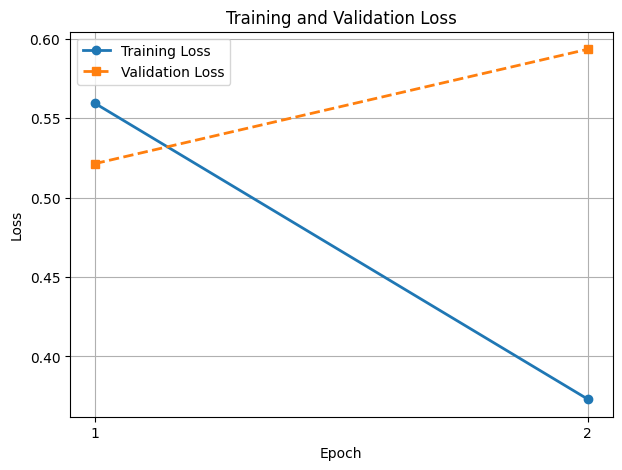

In [1]:
import matplotlib.pyplot as plt

epochs = [1, 2]
train_loss = [0.559526, 0.373029]
val_loss = [0.521403, 0.593505]

plt.figure(figsize=(7,5))

plt.plot(epochs, train_loss, marker='o', linewidth=2, label='Training Loss')
plt.plot(epochs, val_loss, marker='s', linewidth=2, linestyle='--', label='Validation Loss')

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True)
plt.legend()

plt.show()

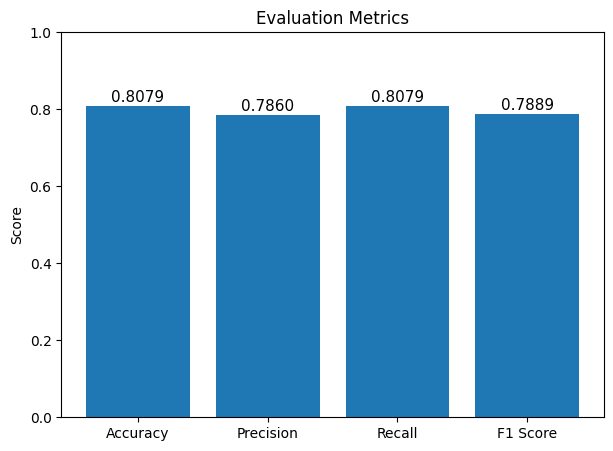

In [2]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
scores = [0.8079, 0.7860, 0.8079, 0.7889]

plt.figure(figsize=(7,5))

bars = plt.bar(metrics, scores)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             y+0.01,
             f"{y:.4f}",
             ha="center",
             fontsize=11)

plt.ylim(0,1)

plt.ylabel("Score")
plt.title("Evaluation Metrics")

plt.show()

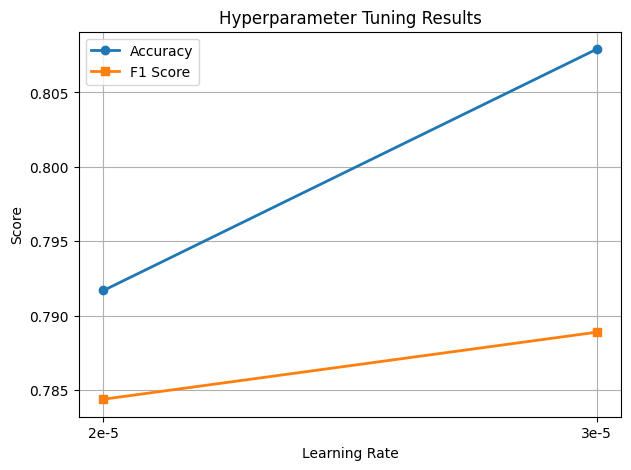

In [3]:
import matplotlib.pyplot as plt

learning_rates = ["2e-5", "3e-5"]

accuracy = [0.7917, 0.8079]
f1 = [0.7844, 0.7889]

x = range(len(learning_rates))

plt.figure(figsize=(7,5))

plt.plot(x, accuracy, marker='o', linewidth=2, label='Accuracy')
plt.plot(x, f1, marker='s', linewidth=2, label='F1 Score')

plt.xticks(x, learning_rates)

plt.xlabel("Learning Rate")
plt.ylabel("Score")
plt.title("Hyperparameter Tuning Results")
plt.legend()
plt.grid(True)

plt.show()

In [5]:
import pandas as pd

comparison = pd.DataFrame({
    "Learning Rate":["2e-5","3e-5"],
    "Accuracy":[0.7917,0.8079],
    "Precision":[0.7794,0.7860],
    "Recall":[0.7917,0.8079],
    "F1 Score":[0.7844,0.7889]
})

comparison

,Learning Rate,Accuracy,Precision,Recall,F1 Score
0,2e-5,0.7917,0.7794,0.7917,0.7844
1,3e-5,0.8079,0.7860,0.8079,0.7889


In [6]:
summary = pd.DataFrame({
    "Parameter":[
        "Model",
        "Dataset",
        "Classes",
        "Epochs",
        "Batch Size",
        "Learning Rate",
        "Weight Decay",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value":[
        "bert-base-uncased",
        "Amazon Kindle Reviews",
        "3",
        2,
        8,
        "3e-5",
        0.01,
        0.8079,
        0.7860,
        0.8079,
        0.7889
    ]
})

summary

,Parameter,Value
0,Model,bert-base-uncased
1,Dataset,Amazon Kindle Reviews
2,Classes,3
3,Epochs,2
4,Batch Size,8
5,Learning Rate,3e-5
6,Weight Decay,0.01
7,Accuracy,0.8079
8,Precision,0.786
9,Recall,0.8079


In [8]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "./BERT_lr3e5/checkpoint-2400"
)

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

print("Model Loaded Successfully!")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 206.89it/s, Materializing param=classifier.weight]                                      


Model Loaded Successfully!


In [9]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)

print("Classifier Ready!")

Classifier Ready!


In [10]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)

samples = [
    "Excellent book. Highly recommended!",
    "The book was average and okay.",
    "Worst book I have ever read.",
    "Amazing story and wonderful characters.",
    "Very boring and disappointing."
]

for text in samples:
    prediction = classifier(text)[0]

    print("="*60)
    print("Review :", text)
    print("Prediction :", prediction["label"])
    print("Confidence :", round(prediction["score"],4))

Review : Excellent book. Highly recommended!
Prediction : LABEL_2
Confidence : 0.9949
Review : The book was average and okay.
Prediction : LABEL_1
Confidence : 0.9062
Review : Worst book I have ever read.
Prediction : LABEL_0
Confidence : 0.9941
Review : Amazing story and wonderful characters.
Prediction : LABEL_2
Confidence : 0.9945
Review : Very boring and disappointing.
Prediction : LABEL_0
Confidence : 0.9924


In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from datasets import Dataset

from transformers import AutoTokenizer

In [17]:
df = pd.read_csv("all_kindle_review .csv")

print(df.shape)

df.head()

(12000, 11)


,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [18]:
df["processed_text"] = df["reviewText"].astype(str)

def convert_label(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["label"] = df["rating"].apply(convert_label)

df[["processed_text","label"]].head()

,processed_text,label
0,"Jace Rankin may be short, but he's nothing to ...",Neutral
1,Great short read. I didn't want to put it dow...,Positive
2,I'll start by saying this is the first of four...,Neutral
3,Aggie is Angela Lansbury who carries pocketboo...,Neutral
4,I did not expect this type of book to be in li...,Positive


In [19]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)

['Negative' 'Neutral' 'Positive']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    df["processed_text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

In [21]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [22]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [23]:
test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

test_dataset = Dataset.from_pandas(test_df)

test_dataset = test_dataset.map(tokenize, batched=True)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

print(test_dataset)

Map: 100%|██████████| 2400/2400 [00:00<00:00, 2742.28 examples/s]

Dataset({
    features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2400
})


In [25]:
from transformers import Trainer

trainer = Trainer(
    model=model
)

print("Trainer Ready!")

Trainer Ready!


In [26]:
predictions = trainer.predict(test_dataset)

y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=1)

print("Predictions Generated Successfully!")

c:\Users\dharm\anaconda3\envs\fyp_env\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predictions Generated Successfully!


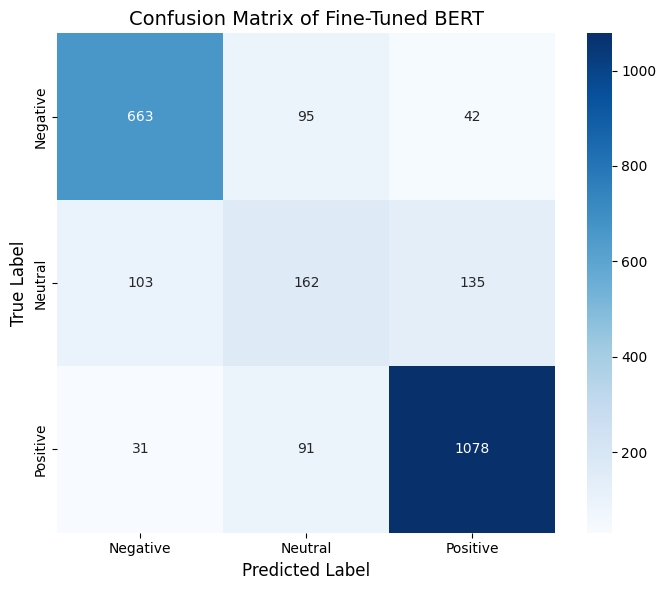

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Neutral","Positive"],
    yticklabels=["Negative","Neutral","Positive"]
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix of Fine-Tuned BERT", fontsize=14)

plt.tight_layout()

plt.savefig("BERT_Confusion_Matrix.png", dpi=300)

plt.show()

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negative","Neutral","Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.83      0.83      0.83       800
     Neutral       0.47      0.41      0.43       400
    Positive       0.86      0.90      0.88      1200

    accuracy                           0.79      2400
   macro avg       0.72      0.71      0.71      2400
weighted avg       0.78      0.79      0.79      2400



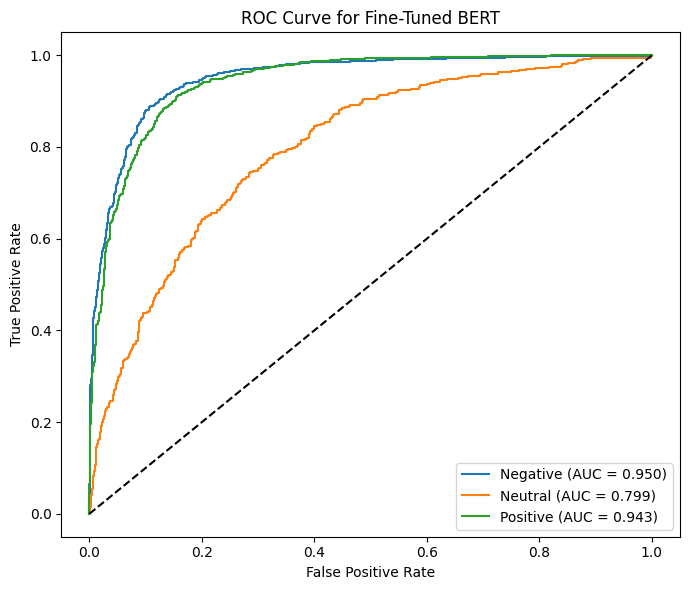

In [30]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_score = predictions.predictions

y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure(figsize=(7,6))

for i, label in enumerate(["Negative","Neutral","Positive"]):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Fine-Tuned BERT")
plt.legend()

plt.tight_layout()

plt.savefig("BERT_ROC_Curve.png", dpi=300)

plt.show()